In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "9"

In [2]:
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [3]:
data = pd.read_csv("smartcart_customers.csv")

In [4]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [5]:
# Feature Engineering
data["Age"] = 2026 - data["Year_Birth"] 
data["Child_at_Home"] = data["Kidhome"] + data["Teenhome"]

data["Customers_puchases"] = (data["NumWebPurchases"] +
                            data["NumCatalogPurchases"] +
                            data["NumStorePurchases"] )

data["Customers_spending"] = (
    data["MntWines"]+
    data["MntFruits"]+
    data["MntMeatProducts"]+
    data["MntFishProducts"]+
    data["MntSweetProducts"]+
    data["MntGoldProds"]
)

data["Education"] = data["Education"].replace({
    "PhD":"Postgraduation", "Master":"Postgraduation",
    "Graduate":"Graduation",
    "Basic" : "Undergraduation", "2n Cycle" : "Undergraduation"
})

data["Marital_Status"] = data["Marital_Status"].replace({
    "Single" : "Single" , "Alone" : "Single" , "Absurd" : "Single", "YOLO" : "Single", "Divorced" :"Single",
    "Widow" : "Single",
    "Together" : "Together" , "Married" : "Together"
})

data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], dayfirst=True)
reference_date = data["Dt_Customer"].max()
data["Customer_Join"] = (reference_date - data["Dt_Customer"]).dt.days

In [6]:
impute = SimpleImputer(strategy="median")

data[["Income"]] = impute.fit_transform(data[["Income"]])

In [7]:
# LabelEncodeing
le = LabelEncoder()

data["Education"] = le.fit_transform(data["Education"])
data["Marital_Status"] = le.fit_transform(data["Marital_Status"])

In [8]:
drop_columns = ["ID", "Year_Birth", "Kidhome", "Teenhome", "Dt_Customer",
               "MntWines", "MntWines", "MntMeatProducts", "MntFishProducts", "MntSweetProducts",
               "MntGoldProds", "NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases",
               "NumStorePurchases", "NumWebVisitsMonth", "MntFruits"]

data_cleaned = data.drop(columns = drop_columns)


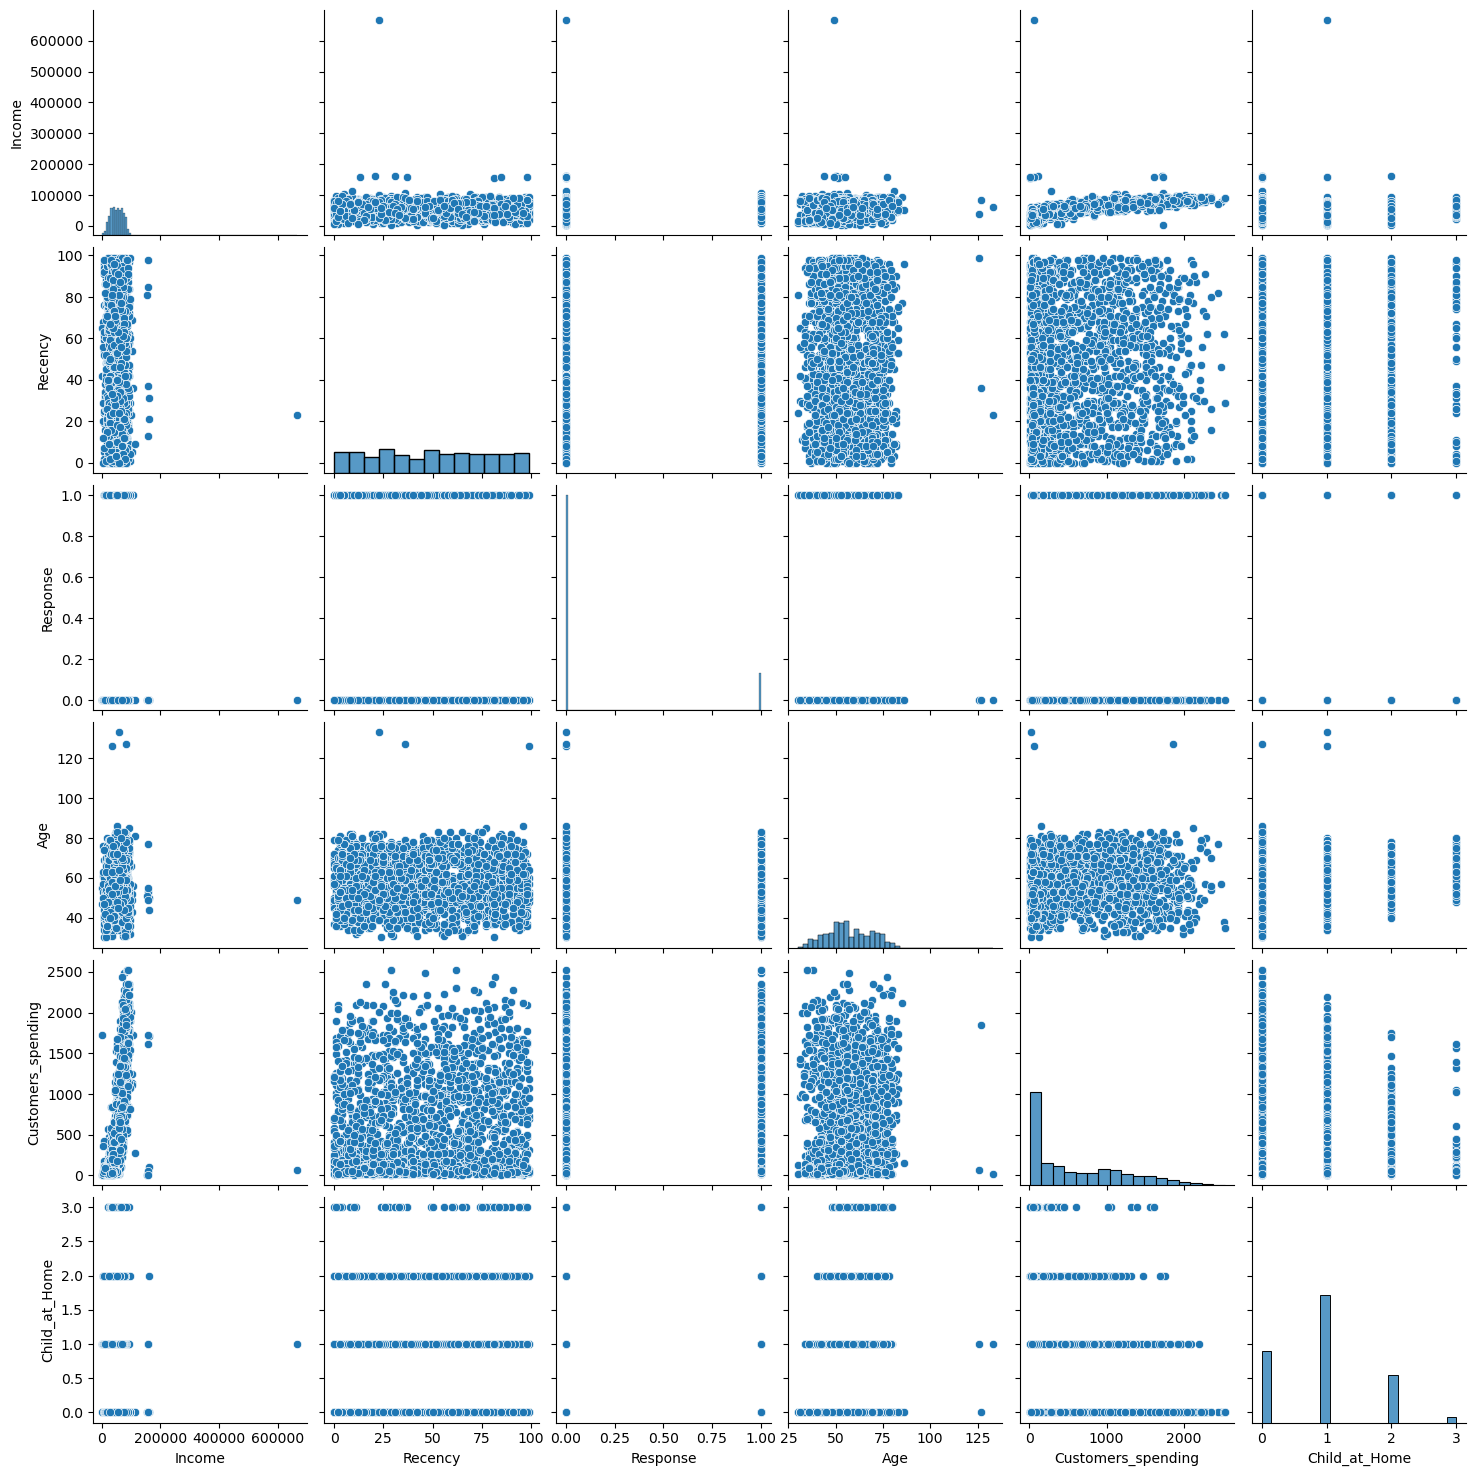

In [9]:
# Outlier removal
col = ["Income", "Recency", "Response", "Age", "Customers_spending", "Child_at_Home"]

sns.pairplot(data_cleaned[col])

In [10]:
print("Data with Outlier :" ,len(data_cleaned))

data_cleaned = data_cleaned[(data_cleaned["Age"] < 90)]
data_cleaned = data_cleaned[(data_cleaned["Income"] < 600_000)]

print("Data without Outlier :", len(data_cleaned))

Data with Outlier : 2240
Data without Outlier : 2236


<Axes: >

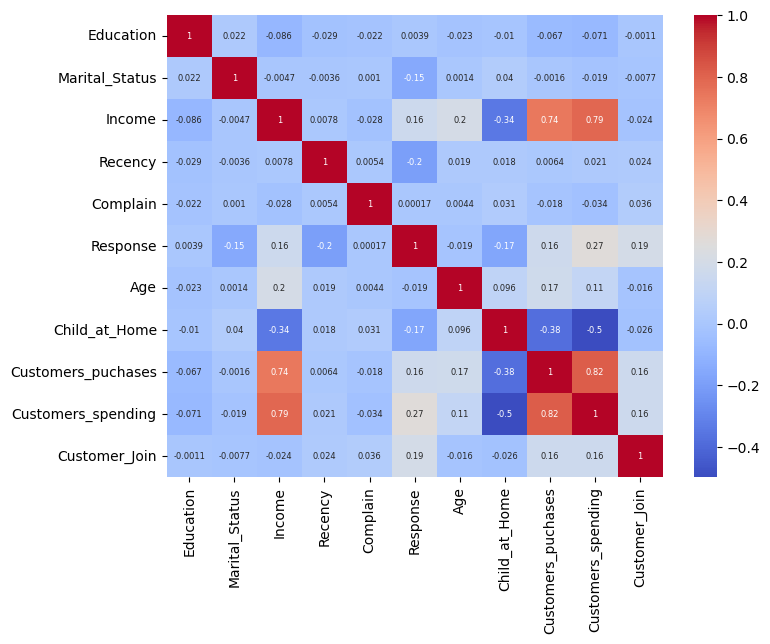

In [11]:
# Heatmap
corr = data_cleaned.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size" : 6},
    cmap="coolwarm"
)

In [12]:
X = data_cleaned.drop(["Response"], axis=1)
y = data_cleaned["Response"]


In [13]:
# Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [14]:
# Visvalize
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

pca.explained_variance_ratio_

array([0.28901723, 0.11189789, 0.10642814])

Text(0.5, 0, 'PCA3')

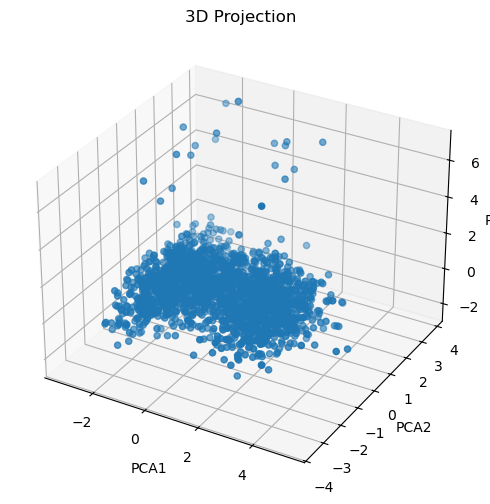

In [15]:
# plot
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_title("3D Projection")
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")

In [16]:
# Elbow maethod
from kneed import KneeLocator

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [17]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")

optimal_k = knee.elbow

print("Best k : ", optimal_k)

Best k :  3


Text(0, 0.5, 'WCSS')

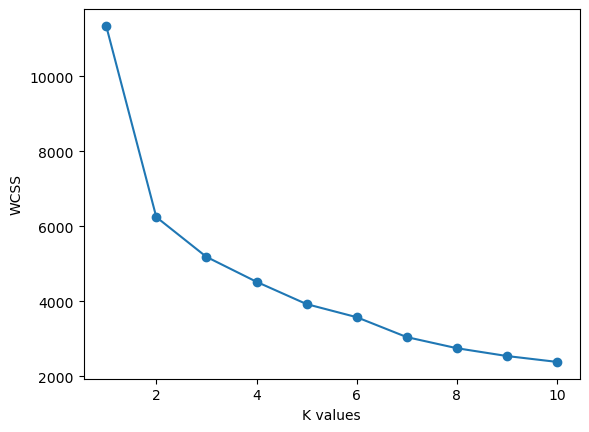

In [21]:
# plot
plt.plot(range(1,11), wcss, marker="o")

plt.xlabel("K values")
plt.ylabel("WCSS")

Text(0, 0.5, 'Silhouette score')

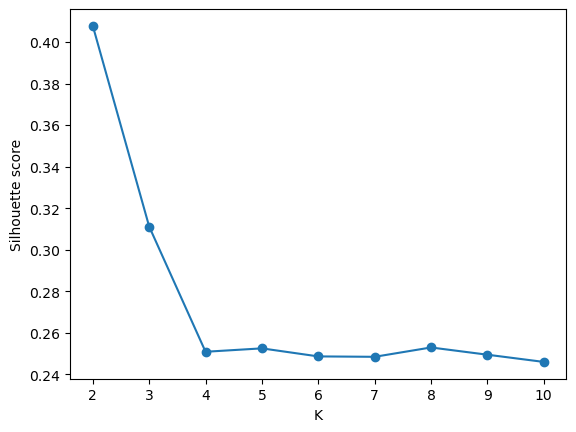

In [22]:
# Silhuette scores
scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

# plot
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'SS')

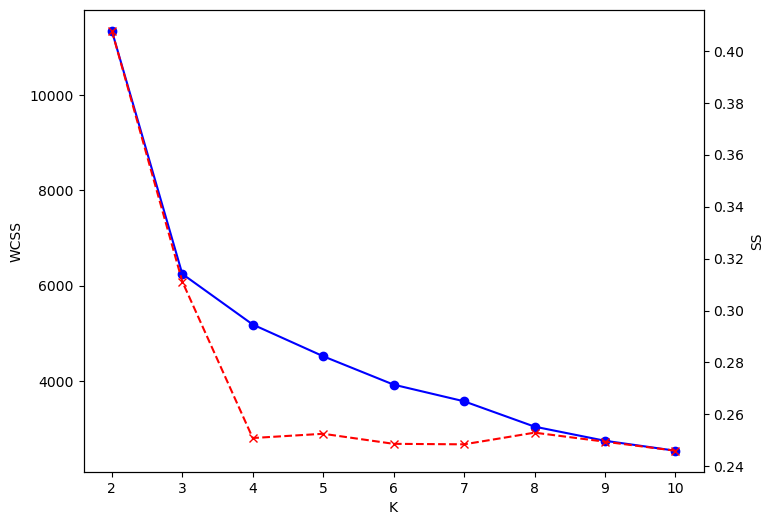

In [23]:
# combined plot

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue") 
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

In [26]:
# clustering

kmeans = KMeans(n_clusters=3, random_state=42)

label_kmeans = kmeans.fit_predict(X_pca)

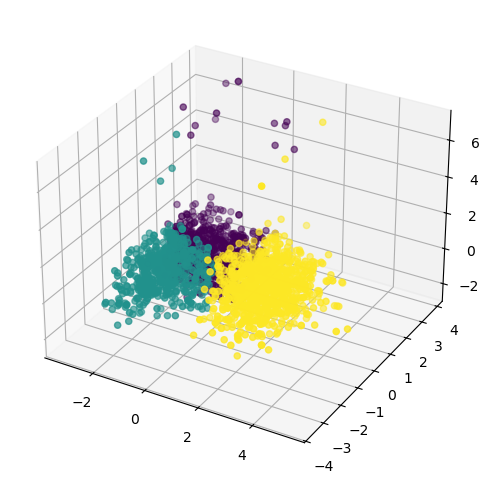

In [28]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=label_kmeans)

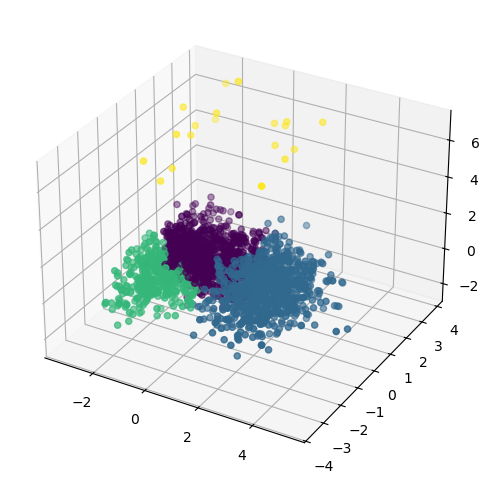

In [29]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)

# Characteristic of cluster



<Axes: xlabel='cluster', ylabel='count'>

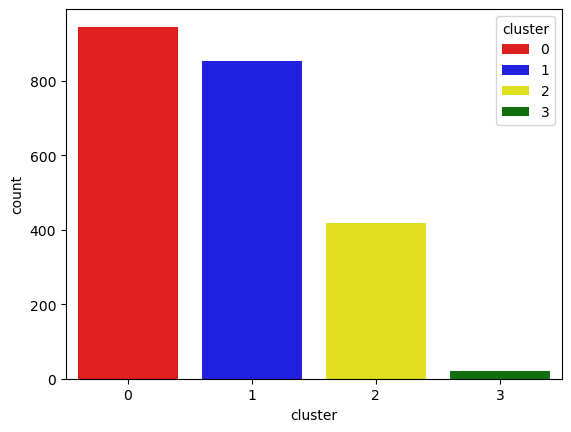

In [30]:
X["cluster"] = labels_agg

pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Customers_spending', ylabel='Income'>

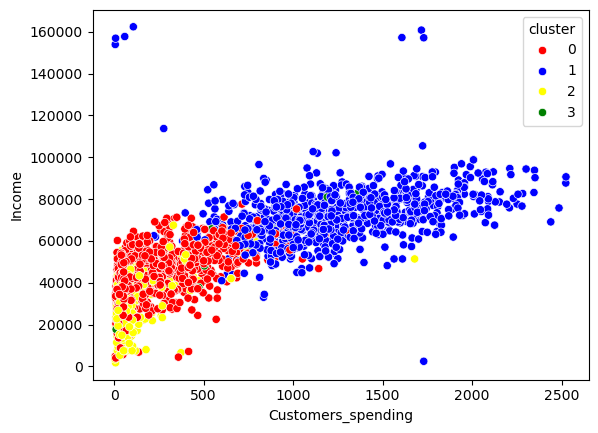

In [32]:
# Income & Spending patterns

sns.scatterplot(x=X["Customers_spending"], y=X["Income"], hue=X["cluster"], palette=pal)